In [46]:
!pip install optuna

In [47]:
# Importing the libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [48]:
# Prepare your data

df = pd.read_csv('/content/cancer-risk-factors.csv')

In [49]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [50]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type'])

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(df['Risk_Level'])

In [51]:
X

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
0,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5
1,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9
2,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2
3,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7
4,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,60,1,4,6,4,0,10,6,4,4,5,3,1,0,4,0.437539,30.3,3
1996,84,1,5,7,8,0,10,0,1,2,1,3,0,0,2,0.451128,25.9,4
1997,65,0,7,2,10,0,4,2,2,3,6,0,0,1,0,0.295760,22.5,3
1998,64,1,10,2,10,0,2,10,7,5,4,2,0,0,10,0.422201,25.3,3


In [52]:
y

array([2, 2, 2, ..., 1, 2, 2])

## why cancer_type was removed from the features list

- It's not a predictive input - it's an outcome label or categorical grouping that's already strongly correlated with Risk Level

- If we include it, the model will cheat by learning the mapping like Prostate --> High risk, instead of learning from true risk factors (smoking, BMI etc)

In [53]:
# Split into training/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [54]:
# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        20
         Low       1.00      1.00      1.00        65
      Medium       1.00      1.00      1.00       315

    accuracy                           1.00       400
   macro avg       1.00      0.98      0.99       400
weighted avg       1.00      1.00      1.00       400

Confusion Matrix
[[ 19   0   1]
 [  0  65   0]
 [  0   0 315]]


The model accurately distinguishes all risk levels, with only 1 mistake out of 400 with imbalanced dataset.

## Logistic Regression

In [57]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [58]:
y_pred_lr = log_reg.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.80      0.89        20
         Low       0.97      0.95      0.96        65
      Medium       0.98      0.99      0.99       315

    accuracy                           0.98       400
   macro avg       0.98      0.92      0.95       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix
[[ 16   0   4]
 [  0  62   3]
 [  0   2 313]]


## Removing Overall_Risk_Score and retrying

In [59]:
X_new = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])

# Encode the target variable
le_new = LabelEncoder()
y_new = le_new.fit_transform(df['Risk_Level'])

In [60]:
# Split into training/test

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size = 0.2, random_state=42, stratify=y)

In [61]:
# Feature Scaling

scaler_new = StandardScaler()
X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

In [62]:
model_new = RandomForestClassifier(random_state=42, n_estimators=100)
model_new.fit(X_train_new, y_train_new)

RandomForestClassifier(random_state=42)

In [63]:
y_pred_new = model_new.predict(X_test_new)

print("Classification Report")
print(classification_report(y_test_new, y_pred_new, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test_new, y_pred_new))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.05      0.10        20
         Low       0.85      0.34      0.48        65
      Medium       0.83      0.99      0.90       315

    accuracy                           0.83       400
   macro avg       0.89      0.46      0.49       400
weighted avg       0.84      0.83      0.80       400

Confusion Matrix
[[  1   0  19]
 [  0  22  43]
 [  0   4 311]]


In [64]:
df.Risk_Level.value_counts()

,count
Risk_Level,
Medium,1574
Low,324
High,102


## SMOTE - Synthetic Minority Over-Sampling Technique

In [80]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])
y = df['Risk_Level']

In [81]:
# Split into training/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [82]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train,y_train)

print("Class Distribution")
print(y_train_res.value_counts())

Class Distribution
Risk_Level
Medium    1259
Low       1259
High      1259
Name: count, dtype: int64


In [83]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [85]:
y_pred = rf_model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        High       0.41      0.35      0.38        20
         Low       0.73      0.58      0.65        65
      Medium       0.88      0.92      0.90       315

    accuracy                           0.84       400
   macro avg       0.67      0.62      0.64       400
weighted avg       0.83      0.84      0.83       400

Confusion Matrix
[[  7   0  13]
 [  0  38  27]
 [ 10  14 291]]


- Accuracy: 84%
- High Risk: 7 correctly classified, 13 mis-classified as Medium
- Low Risk: 38 correctly classified, 27 confused with Medium
- Medium Risk: 291 correctly classified, 24 confused as High/Low

- Still struggles to detect High-risk patients even with SMOTE

## Optuna Tuning

In [86]:
# Optuna tuning
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

import numpy as np
import joblib  # optional, to save model/study

In [87]:
X_train_res.shape

(3777, 17)

In [88]:
from sklearn.metrics import f1_score, make_scorer

# Define macro F1 scorer explicitly for multiclass
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

scorer = make_scorer(macro_f1)


In [89]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_res, y_train_res):
        X_t, X_v = X_train_res.iloc[train_idx], X_train_res.iloc[val_idx]
        y_t, y_v = y_train_res.iloc[train_idx], y_train_res.iloc[val_idx]

        model.fit(X_t, y_t)
        y_pred = model.predict(X_v)

        score = f1_score(y_v, y_pred, average='macro')  # explicit multiclass handling
        scores.append(score)

    return np.mean(scores)

In [90]:
# --- Create study ---
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='rf_macro_f1')


[I 2025-12-18 15:38:00,647] A new study created in memory with name: rf_macro_f1


In [74]:
# --- Run optimization ---
n_trials = 50  # change to 100+ if you want more thorough search
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 15:28:32,964] Trial 0 finished with value: 0.9402356457892479 and parameters: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9402356457892479.
[I 2025-12-18 15:28:33,946] Trial 1 finished with value: 0.9488676606640238 and parameters: {'n_estimators': 59, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.
[I 2025-12-18 15:28:37,708] Trial 2 finished with value: 0.9045887437906642 and parameters: {'n_estimators': 325, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.
[I 2025-12-18 15:28:41,881] Trial 3 finished with value: 0.9089885645353499 and parameters: {'n_estimators': 324, 'max_dept

In [92]:
# Train final model with best params and full training data, then evaluate on test
best_params = {
    'n_estimators': 347,
    'max_depth': 19,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': False,
    'criterion': 'gini',
    'random_state': 42,
    'n_jobs': -1
}


final_rf = RandomForestClassifier(**best_params)
final_rf.fit(X_train_res, y_train_res)         # resampled training set
y_pred_test = final_rf.predict(X_test)        # untouched test set

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))


              precision    recall  f1-score   support

        High       0.36      0.25      0.29        20
         Low       0.72      0.58      0.64        65
      Medium       0.87      0.92      0.90       315

    accuracy                           0.83       400
   macro avg       0.65      0.59      0.61       400
weighted avg       0.82      0.83      0.83       400

[[  5   0  15]
 [  0  38  27]
 [  9  15 291]]


In [93]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer, recall_score
import optuna
import numpy as np

# scorer (macro f1)
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

macro_f1_scorer = make_scorer(macro_f1)

def objective(trial):
    # RF params to try
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 6, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt','log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini','entropy']),
        'random_state': 42,
        'n_jobs': 1   # avoid nested parallelism inside cross_val_score
    }

    sm = SMOTE(random_state=42)
    rf = RandomForestClassifier(**params)
    pipe = ImbPipeline([('smote', sm), ('rf', rf)])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=macro_f1_scorer, n_jobs=1)
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)
print(study.best_value, study.best_params)


[I 2025-12-18 15:48:59,787] A new study created in memory with name: no-name-03575131-db66-4a49-b005-26df093dfdb0
[I 2025-12-18 15:49:03,649] Trial 0 finished with value: 0.671473898202647 and parameters: {'n_estimators': 212, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.671473898202647.
[I 2025-12-18 15:49:05,628] Trial 1 finished with value: 0.6657242146375855 and parameters: {'n_estimators': 106, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.671473898202647.
[I 2025-12-18 15:49:11,245] Trial 2 finished with value: 0.6616028068735651 and parameters: {'n_estimators': 284, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.671473898202647.
[I 2025-12-1

0.6955465581227341 {'n_estimators': 119, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}


In [94]:
# Suppose best_params from study:
best = study.best_params
rf = RandomForestClassifier(**best, random_state=42, n_jobs=-1)

pipe_final = ImbPipeline([('smote', SMOTE(random_state=42)), ('rf', rf)])
pipe_final.fit(X_train, y_train)   # fit on original X_train (pipeline will SMOTE inside)

y_test_pred = pipe_final.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


              precision    recall  f1-score   support

        High       0.35      0.45      0.39        20
         Low       0.71      0.63      0.67        65
      Medium       0.89      0.89      0.89       315

    accuracy                           0.83       400
   macro avg       0.65      0.66      0.65       400
weighted avg       0.83      0.83      0.83       400

[[  9   0  11]
 [  0  41  24]
 [ 17  17 281]]


## **XGBoost**

In [97]:
# baseline XGBoost (SMOTE inside pipeline - no leakage)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# Build Pipeline
xgb = XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss', random_state=42, n_jobs=-1)
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

pipe.fit(X_train, y_train_enc)

y_pred_enc = pipe.predict(X_test)

y_pred = le.inverse_transform(y_pred_enc)
y_test_orig = le.inverse_transform(y_test_enc)

print("Baseline XGB Classifier")
print(classification_report(y_test_orig, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test_orig, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:01:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline XGB Classifier
              precision    recall  f1-score   support

        High       0.39      0.45      0.42        20
         Low       0.79      0.68      0.73        65
      Medium       0.90      0.92      0.91       315

    accuracy                           0.85       400
   macro avg       0.69      0.68      0.68       400
weighted avg       0.86      0.85      0.85       400

Confusion Matrix
[[  9   0  11]
 [  0  44  21]
 [ 14  12 289]]


In [98]:
## Optuna + XGBoost pipeline that optimizes recall for the High class.

# --- Imports ---
import optuna
from optuna.samplers import TPESampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- Settings ---
TARGET_LABEL = 'High'       # label whose recall we want to maximize
LABEL_ORDER = ['High', 'Low', 'Medium']  # must match your label names exactly
N_TRIALS = 40               # start with 40; increase to 100+ for more thorough search
CV_FOLDS = 3

# --- Encode labels once (keep mapping stable) ---
le = LabelEncoder()
le.fit(y_train)               # fit on training labels (or whole y if preferred)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
# numeric index of target label in encoded space
target_index = int(np.where(le.classes_ == TARGET_LABEL)[0])

# --- Objective: maximize recall for TARGET_LABEL ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        # stable args
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss'
    }

    # Build pipeline (SMOTE on training folds only)
    xgb = XGBClassifier(**params, n_jobs=1)   # n_jobs=1 to avoid nested parallelism in CV
    pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('xgb', xgb)])

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[train_idx], y_train_enc[val_idx]

        pipe.fit(X_t, y_t)
        y_pred = pipe.predict(X_v)

        # compute recall per class in LABEL_ORDER and select target_index
        recs = recall_score(y_v, y_pred, labels=list(range(len(le.classes_))), average=None, zero_division=0)
        recall_high = recs[target_index]
        recalls.append(recall_high)

    return float(np.mean(recalls))

# --- Run Optuna study ---
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='xgb_high_recall')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest CV mean High-recall:", study.best_value)
print("Best params:")
for k,v in study.best_params.items():
    print(f"  {k}: {v}")

# --- Train final pipeline with best params and evaluate on test set ---
best_params = study.best_params.copy()
# ensure required fixed args for final fit
best_params.update({'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42})
final_xgb = XGBClassifier(**best_params, n_jobs=-1)

final_pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('xgb', final_xgb)])
# fit with encoded y (pipeline will apply SMOTE inside)
final_pipe.fit(X_train, y_train_enc)

# predict (encoded), then decode for readable report
y_test_pred_enc = final_pipe.predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred_enc)
y_test_orig = y_test  # original readable labels

print("\nFINAL Test Classification Report (labels in original names):")
print(classification_report(y_test_orig, y_test_pred, labels=le.classes_))
print("Confusion Matrix (rows=true, cols=predicted, order = le.classes_):")
print(confusion_matrix(y_test_orig, y_test_pred, labels=le.classes_))


/tmp/ipython-input-2797660010.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  target_index = int(np.where(le.classes_ == TARGET_LABEL)[0])
[I 2025-12-18 16:04:54,752] A new study created in memory with name: xgb_high_recall


  0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipython-input-2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-12-18 16:04:56,186] Trial 0 finished with value: 0.47707231040564374 and parameters: {'n_estimators': 181, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.4936111842654619, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.47707231040564374.


/tmp/ipython-input-2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-12-18 16:05:57,773] Trial 38 finished with value: 0.4902998236331569 and parameters: {'n_estimators': 173, 'max_depth': 11, 'learning_rate': 0.05926910220861335, 'subsample': 0.7016493299308334, 'colsample_bytree': 0.731244503150849, 'gamma': 0.01333980638640675, 'reg_alpha': 4.732368793214298, 'reg_lambda': 3.575893223992021}. Best is trial 19 with value: 0.7217813051146384.


/tmp/ipython-input-2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:05:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-12-18 16:05:58,396] Trial 39 finished with value: 0.6238977072310404 and parameters: {'n_estimators': 83, 'max_depth': 3, 'learning_rate': 0.2053991013800601, 'subsample': 0.9803352379816824, 'colsample_bytree': 0.840574492040825, 'gamma': 4.68038837351997, 'reg_alpha': 0.6661220582755636, 'reg_lambda': 2.495828683138461}. Best is trial 19 with value: 0.7217813051146384.

Best CV mean High-recall: 0.7217813051146384
Best params:
  n_estimators: 105
  max_depth: 3
  learning_rate: 0.014843806162322944
  subsample: 0.7730982444721965
  colsample_bytree: 0.8509237341976973
  gamma: 4.134336554829186
  reg_alpha: 4.453508368364819
  reg_lambda: 2.616923339470738


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



FINAL Test Classification Report (labels in original names):
              precision    recall  f1-score   support

        High       0.15      0.65      0.25        20
         Low       0.44      0.71      0.54        65
      Medium       0.88      0.59      0.71       315

    accuracy                           0.61       400
   macro avg       0.49      0.65      0.50       400
weighted avg       0.77      0.61      0.66       400

Confusion Matrix (rows=true, cols=predicted, order = le.classes_):
[[ 13   0   7]
 [  1  46  18]
 [ 70  59 186]]


In [99]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Encode target labels (if not already numeric)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Compute class weights inversely proportional to class frequencies
classes, counts = np.unique(y_train_enc, return_counts=True)
class_weights = {cls: max(counts)/count for cls, count in zip(classes, counts)}
print("Class Weights:", class_weights)

# 3. Initialize XGBoost with weights
xgb_weighted = XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=105,
    max_depth=3,
    learning_rate=0.014843806162322944,
    subsample=0.7730982444721965,
    colsample_bytree=0.8509237341976973,
    gamma=4.134336554829186,
    reg_alpha=4.453508368364819,
    reg_lambda=2.616923339470738,
    n_jobs=-1
)

# 4. Fit model with per-sample weights
sample_weights = np.array([class_weights[y] for y in y_train_enc])
xgb_weighted.fit(X_train, y_train_enc, sample_weight=sample_weights)

# 5. Evaluate
y_pred_enc = xgb_weighted.predict(X_test)
print("Class-weighted XGBoost - Classification Report")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))
print("Confusion Matrix")
print(confusion_matrix(y_test_enc, y_pred_enc))


Class Weights: {np.int64(0): np.float64(15.353658536585366), np.int64(1): np.float64(4.861003861003861), np.int64(2): np.float64(1.0)}
Class-weighted XGBoost - Classification Report
              precision    recall  f1-score   support

        High       0.21      0.75      0.33        20
         Low       0.42      0.82      0.56        65
      Medium       0.92      0.59      0.72       315

    accuracy                           0.64       400
   macro avg       0.52      0.72      0.54       400
weighted avg       0.80      0.64      0.67       400

Confusion Matrix
[[ 15   0   5]
 [  0  53  12]
 [ 56  72 187]]


In [100]:
# Optuna tuning for class-weighted XGBoost (optimize macro-F1)
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ----------------------
# Prepare encoded labels
# ----------------------
le = LabelEncoder()
le.fit(y_train)               # fit encoder on training labels
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
n_classes = len(le.classes_)

# ----------------------
# Objective: maximize macro-F1
# ----------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        # stable args:
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        # set n_jobs=1 inside CV to avoid nested parallelism
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[train_idx], y_train_enc[val_idx]

        # compute class weights from the fold's training data
        classes, counts = np.unique(y_t, return_counts=True)
        # simple inverse frequency scaling
        class_weight_map = {cls: float(max(counts) / cnt) for cls, cnt in zip(classes, counts)}
        sample_weights = np.array([class_weight_map[y] for y in y_t])

        # instantiate classifier with n_jobs=1 for CV
        model = XGBClassifier(**params, n_jobs=1, random_state=42)

        # fit with per-sample weights
        model.fit(X_t, y_t, sample_weight=sample_weights, verbose=False)

        y_pred = model.predict(X_v)
        scores.append(f1_score(y_v, y_pred, average='macro'))

    # return mean macro-F1 across folds
    return float(np.mean(scores))

# ----------------------
# Run Optuna study
# ----------------------
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='xgb_class_weighted_macroF1')

# fewer trials to start; increase to 50-150 when comfortable
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best CV macro-F1:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ----------------------
# Train final model on full training set using class weights
# ----------------------
best = study.best_params.copy()
best.update({'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42})

# compute final sample weights from full training set
classes, counts = np.unique(y_train_enc, return_counts=True)
final_class_weight_map = {cls: float(max(counts)/cnt) for cls, cnt in zip(classes, counts)}
final_sample_weights = np.array([final_class_weight_map[y] for y in y_train_enc])

final_xgb = XGBClassifier(**best, n_jobs=-1)
final_xgb.fit(X_train, y_train_enc, sample_weight=final_sample_weights, verbose=False)

# Evaluate on untouched test set
y_test_pred_enc = final_xgb.predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred_enc)
y_test_orig = y_test  # already readable labels

print("\nFINAL Test Classification Report (class-weighted XGB):")
print(classification_report(y_test_orig, y_test_pred, labels=le.classes_))
print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test_orig, y_test_pred, labels=le.classes_))


[I 2025-12-18 16:07:16,865] A new study created in memory with name: xgb_class_weighted_macroF1


  0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipython-input-3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:07:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:07:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:07:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-12-18 16:07:18,674] Trial 0 finished with value: 0.6879837748303802 and parameters: {'n_estimators': 181, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.4936111842654619, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.6879837748303802.


/tmp/ipython-input-3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:07:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:07:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:07:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-12-18 16:08:08,441] Trial 38 finished with value: 0.6798862044080721 and parameters: {'n_estimators': 259, 'max_depth': 8, 'learning_rate': 0.00919645840876204, 'subsample': 0.6794659132887013, 'colsample_bytree': 0.6757617428415484, 'gamma': 3.8370761624114746, 'reg_alpha': 0.03888773665934271, 'reg_lambda': 3.145986656035028}. Best is trial 23 with value: 0.7166611235474899.


/tmp/ipython-input-3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:08:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:08:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:08:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-12-18 16:08:10,988] Trial 39 finished with value: 0.6904798040669227 and parameters: {'n_estimators': 296, 'max_depth': 11, 'learning_rate': 0.005194506606124497, 'subsample': 0.7153235539820004, 'colsample_bytree': 0.7712413594130637, 'gamma': 0.28357008456076105, 'reg_alpha': 0.7602632749952242, 'reg_lambda': 4.65409196552969}. Best is trial 23 with value: 0.7166611235474899.
Best CV macro-F1: 0.7166611235474899
Best params:
  n_estimators: 304
  max_depth: 11
  learning_rate: 0.08007286360933288
  subsample: 0.743074596045066
  colsample_bytree: 0.46548655368448905
  gamma: 0.7978753628088727
  reg_alpha: 1.9672780502868439
  reg_lambda: 2.0390163529054015


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:08:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



FINAL Test Classification Report (class-weighted XGB):
              precision    recall  f1-score   support

        High       0.50      0.45      0.47        20
         Low       0.76      0.78      0.77        65
      Medium       0.92      0.92      0.92       315

    accuracy                           0.88       400
   macro avg       0.73      0.72      0.72       400
weighted avg       0.87      0.88      0.87       400

Confusion Matrix (rows=true, cols=pred):
[[  9   0  11]
 [  0  51  14]
 [  9  16 290]]


## Winner: Optuna-Tuned Class-weighted XGBoost

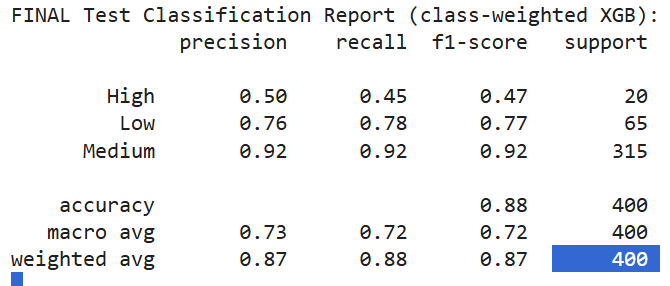

## Save the model as a .pkl file

In [102]:
import joblib

joblib.dump(model,'model_xgb_new.pkl')

print("Model saved successfully as 'model_xgb_new.pkl'")

Model saved successfully as 'model_xgb_new.pkl'
